In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
def relu(Z):
    return np.maximum(0, Z)

In [4]:
def sigmoid(Z):
  A = 1/(1+np.exp(-Z))
  return A
Z = np.array([1,2])
sigmoid(Z)

array([0.73105858, 0.88079708])

In [5]:
def initialize_parameters(layer_dims):
  parameters = {}
  for l in range(1, len(layer_dims)):
    current =   layer_dims[l]
    prev = layer_dims[l-1]
    parameters['W'+str(l)] = np.random.randn(current,prev)
    parameters['b'+str(l)] = np.zeros((current,1))
  return parameters

params = initialize_parameters([2, 4, 1])
print(params['W1'].shape)  # should be (4, 2)
print(params['W2'].shape)  # should be (1, 4)

(4, 2)
(1, 4)


In [6]:
def forwardpass(X, parameters):
  L = len(parameters)//2
  A = X
  cache = {'A0': X} #For backprop

  for i in range(1, L + 1):
    W = parameters['W' + str(i)]
    b = parameters['b'+str(i)]
    Z = np.dot(W, A) + b
    if i == L:
       A = sigmoid(Z)
    else:
      A = relu(Z)
    cache['Z' + str(i)] = Z
    cache['A' + str(i)] = A
  return A, cache

X = np.array([[1], [2]])  # 2 inputs, 1 sample
params = initialize_parameters([2, 4, 1])
A2, cache = forwardpass(X, params)
print(A2.shape)  # should be (1, 1)
print(cache.keys())


(1, 1)
dict_keys(['A0', 'Z1', 'A1', 'Z2', 'A2'])


In [7]:
def compute_loss(A, y, parameters, lamda):
  m = y.shape[1]
  L = len(parameters)//2
  loss = -(1/(m))*np.sum(y*np.log(A)+(1-y)*np.log(1-A))
  l2_loss = 0
  for i in range(1, L + 1):
    l2_loss = l2_loss + (lamda/(2*m)*np.sum(np.square(parameters['W' + str(i)])))
  loss = loss + l2_loss
  return loss
A = np.array([[0.9, 0.1]])
y = np.array([[1, 0]])
print(compute_loss(A, y, params, lamda=0))  # should be a small positive number

0.10536051565782628


In [8]:
def relu_derivative(Z):
  return (Z > 0 ).astype(float)

In [9]:
def backprop(y,cache, parameters, lambd = 0):
    L = len(parameters)//2
    grads = {}
    grads['delta' + str(L)] = cache['A'+ str(L)] - y
    for l in range(L,0,-1):
      delta=grads['delta' + str(l)]
      grads['dW' + str(l)] = (1/y.shape[1])*np.dot(delta, np.transpose(cache['A' + str(l-1)])) + (lambd/y.shape[1])*parameters['W' + str(l)]
      if l > 1:
        grads['delta'+str(l-1)] = np.dot(np.transpose(parameters['W' + str(l)]),delta)*relu_derivative(cache['Z' + str(l-1)])
      grads['db' + str(l)] = (1/(y.shape[1]))*np.sum(delta,axis=1, keepdims = True)

    return grads

X = np.array([[1], [2]])
y = np.array([[1]])

params = initialize_parameters([2, 4, 1])
A, cache = forwardpass(X, params)
grads = backprop(y, cache, params)

print(grads['dW1'].shape)  # should be (4, 2)
print(grads['dW2'].shape)  # should be (1, 4)
print(grads['db1'].shape)  # should be (4, 1)
print(grads['db2'].shape)  # should be (1, 1)


(4, 2)
(1, 4)
(4, 1)
(1, 1)


In [10]:
def update_params(parameters, grads, learning_rate):
  L = len(parameters) // 2
  for i in range(1,L+1):
    parameters['W' + str(i)] = parameters['W' + str(i)] - learning_rate*grads['dW'+str(i)]
    parameters['b' + str(i)] = parameters['b' + str(i)] - learning_rate*grads['db' + str(i)]
  return parameters

In [11]:
def predict(X, params):
  AL, cache = forwardpass(X, params)
  prediction = (AL>0.5).astype(int)
  return prediction

In [12]:
def model(X, y, layer_dims, lamda= 0, epochs=1000, learning_rate=0.01):
  costs = []
  params  = initialize_parameters(layer_dims)
  for i in range(epochs):
    AL, cache = forwardpass(X, params)
    cost = compute_loss(AL, y, params, lamda)
    grads = backprop(y, cache, params, lamda)
    params = update_params(params, grads, learning_rate)
    if i%100 == 0:
      costs.append(cost)
      print(f"{i} number of iterations done...../n Cost: {cost}")
  return params, costs

In [13]:
from sklearn.datasets import make_moons

X, y = make_moons(n_samples=300, noise=0.2, random_state=42)
X = X.T
y = y.reshape(1, -1)
layer_dims = [2, 8, 1]

# Without regularization
params1, _ = model(X, y, layer_dims, lamda=0, epochs=5000, learning_rate=0.1)
pred1 = predict(X, params1)
print(f"No reg accuracy: {np.mean(pred1==y)*100}%")

# With regularization
params2, _ = model(X, y, layer_dims, lamda=0.2, epochs=5000, learning_rate=0.1)
pred2 = predict(X, params2)
print(f"L2 reg accuracy: {np.mean(pred2==y)*100}%")

0 number of iterations done...../n Cost: 2.877860145249175
100 number of iterations done...../n Cost: 0.3765999203467065
200 number of iterations done...../n Cost: 0.32591322936977685
300 number of iterations done...../n Cost: 0.30419633826245496
400 number of iterations done...../n Cost: 0.291113420245577
500 number of iterations done...../n Cost: 0.2813707558742406
600 number of iterations done...../n Cost: 0.27305991025417975
700 number of iterations done...../n Cost: 0.26427044130474364
800 number of iterations done...../n Cost: 0.2532743567095313
900 number of iterations done...../n Cost: 0.24083595419867268
1000 number of iterations done...../n Cost: 0.22856276482685414
1100 number of iterations done...../n Cost: 0.21643022808504517
1200 number of iterations done...../n Cost: 0.20391778670039964
1300 number of iterations done...../n Cost: 0.19138525164355322
1400 number of iterations done...../n Cost: 0.17992046889518454
1500 number of iterations done...../n Cost: 0.1690777714554

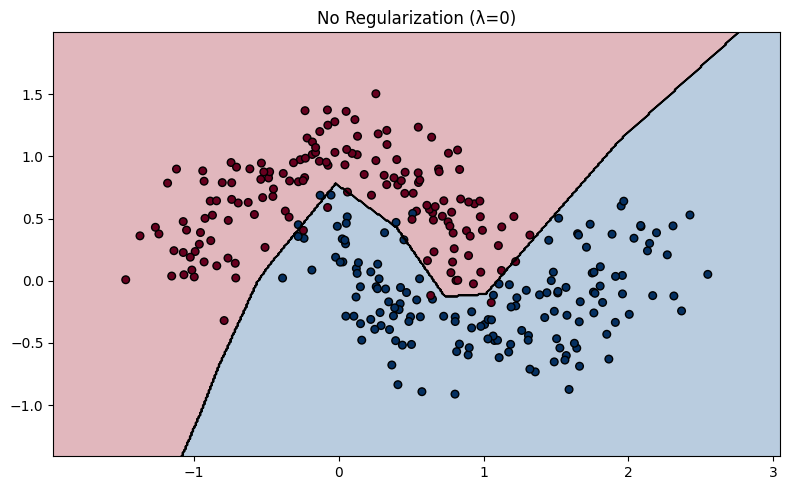

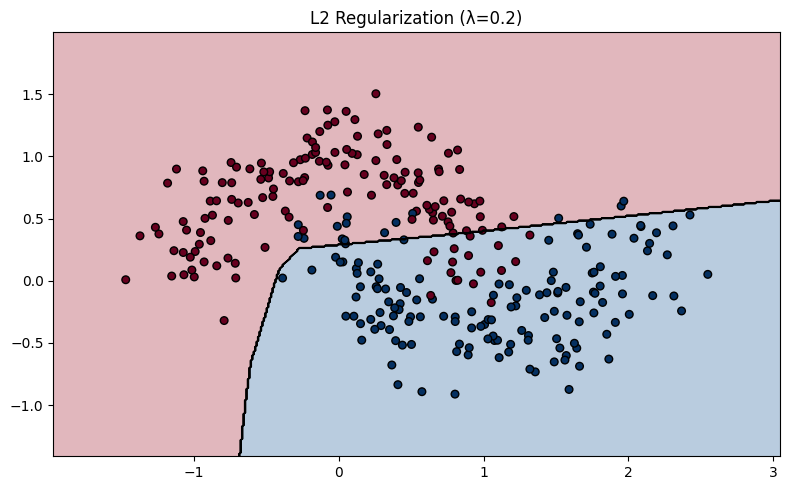

In [16]:
def plot_decision_boundary(X, y, params, title="Decision Boundary"):
    x_min, x_max = X[0].min() - 0.5, X[0].max() + 0.5
    y_min, y_max = X[1].min() - 0.5, X[1].max() + 0.5

    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                         np.arange(y_min, y_max, 0.01))

    grid = np.c_[xx.ravel(), yy.ravel()].T  # shape (2, n_points)
    Z = predict(grid, params)
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(8, 5))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
    plt.contour(xx, yy, Z, colors='k', linewidths=0.8)  # decision boundary line
    plt.scatter(X[0], X[1], c=y[0], cmap='RdBu', edgecolors='k', s=30)
    plt.title(title)
    plt.tight_layout()
    plt.show()

# Call after training
plot_decision_boundary(X, y, params1, title="No Regularization (λ=0)")
plot_decision_boundary(X, y, params2, title="L2 Regularization (λ=0.2)")